# AR Assignment - Part 2 (1.4, 1.5, 1.6)
This notebook completes the AR pipeline by cropping AR frames, warping them to the detected book plane, and writing the final augmented video.

## 1) Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2) Helper Functions (crop, homography, overlay)

In [5]:
def resolve_path(filename):
    # Support both running from repo root and from assignment_2_materials folder
    candidates = [filename, os.path.join('assignment_2_materials', filename)]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f'Could not find file: {filename}')


def crop_center_to_aspect(frame, target_w, target_h):
    # Keep center-crop helper since Part 1.4 requires matching cover aspect ratio before resizing
    h, w = frame.shape[:2]
    target_aspect = target_w / target_h
    frame_aspect = w / h

    if frame_aspect > target_aspect:
        new_w = int(h * target_aspect)
        x0 = (w - new_w) // 2
        cropped = frame[:, x0:x0 + new_w]
    else:
        new_h = int(w / target_aspect)
        y0 = (h - new_h) // 2
        cropped = frame[y0:y0 + new_h, :]

    resized = cv2.resize(cropped, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    return resized


def compute_homography_matrix(src_points, dst_points):
    # TA requirement: use manual homography computation instead of cv2.findHomography in pipeline
    src = np.asarray(src_points, dtype=np.float64).reshape(-1, 2)
    dst = np.asarray(dst_points, dtype=np.float64).reshape(-1, 2)

    if len(src) < 4 or len(dst) < 4 or len(src) != len(dst):
        return None

    A = []
    for i in range(len(src)):
        x_1, y_1 = src[i][0], src[i][1]
        x_2, y_2 = dst[i][0], dst[i][1]
        A.append([x_1, y_1, 1, 0, 0, 0, -x_1 * x_2, -y_1 * x_2, -x_2])
        A.append([0, 0, 0, x_1, y_1, 1, -x_1 * y_2, -y_1 * y_2, -y_2])

    A = np.array(A, dtype=np.float64)
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)

    if abs(H[2, 2]) < 1e-12:
        return None
    H = H / H[2, 2]

    if not np.all(np.isfinite(H)):
        return None
    return H


def get_homography_manual(cover_kp, cover_des, frame_gray, sift, bf, ratio_thresh=0.75, max_used_matches=50):
    # Keep SIFT + KNN + Lowe ratio test, but compute H manually per TA instruction
    frame_kp, frame_des = sift.detectAndCompute(frame_gray, None)
    if frame_des is None or cover_des is None:
        return None, 0, 0

    knn_matches = bf.knnMatch(cover_des, frame_des, k=2)
    good = []
    for pair in knn_matches:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio_thresh * n.distance:
            good.append(m)

    if len(good) < 4:
        return None, len(good), 0

    selected = sorted(good, key=lambda m: m.distance)[:max_used_matches]
    src_pts = np.float32([cover_kp[m.queryIdx].pt for m in selected]).reshape(-1, 2)
    dst_pts = np.float32([frame_kp[m.trainIdx].pt for m in selected]).reshape(-1, 2)

    H = compute_homography_matrix(src_pts, dst_pts)
    if H is None:
        return None, len(good), 0

    return H, len(good), len(selected)


def forward_warp(src_img, H, output_shape):
    # TA requirement: explicit forward warping implementation
    out_h, out_w = output_shape[:2]
    if src_img.ndim == 2:
        output = np.zeros((out_h, out_w), dtype=src_img.dtype)
    else:
        output = np.zeros((out_h, out_w, src_img.shape[2]), dtype=src_img.dtype)

    src_h, src_w = src_img.shape[:2]
    for y in range(src_h):
        for x in range(src_w):
            mapped = H @ np.array([x, y, 1.0], dtype=np.float64)
            if abs(mapped[2]) < 1e-12:
                continue

            x_out = int(round(mapped[0] / mapped[2]))
            y_out = int(round(mapped[1] / mapped[2]))

            if 0 <= x_out < out_w and 0 <= y_out < out_h:
                output[y_out, x_out] = src_img[y, x]

    return output


def inverse_warp(src_img, H, output_shape):
    # TA requirement: final pipeline must use manual inverse warping instead of cv2.warpPerspective
    out_h, out_w = output_shape[:2]
    if src_img.ndim == 2:
        output = np.zeros((out_h, out_w), dtype=src_img.dtype)
    else:
        output = np.zeros((out_h, out_w, src_img.shape[2]), dtype=src_img.dtype)

    H_inv = np.linalg.inv(H)
    src_h, src_w = src_img.shape[:2]

    for y_out in range(out_h):
        for x_out in range(out_w):
            src_hom = H_inv @ np.array([x_out, y_out, 1.0], dtype=np.float64)
            if abs(src_hom[2]) < 1e-12:
                continue

            x_src = src_hom[0] / src_hom[2]
            y_src = src_hom[1] / src_hom[2]

            x_nn = int(round(x_src))
            y_nn = int(round(y_src))

            if 0 <= x_nn < src_w and 0 <= y_nn < src_h:
                output[y_out, x_out] = src_img[y_nn, x_nn]

    return output


def overlay_warped_ar(book_frame, ar_cropped, H, cover_w, cover_h):
    # Keep perspectiveTransform + mask, but replace warpPerspective with manual inverse warp per TA
    corners = np.float32([[0, 0], [cover_w - 1, 0], [cover_w - 1, cover_h - 1], [0, cover_h - 1]]).reshape(-1, 1, 2)
    projected_corners = cv2.perspectiveTransform(corners, H)

    warped_ar = inverse_warp(ar_cropped, H, (book_frame.shape[0], book_frame.shape[1]))

    mask = np.zeros(book_frame.shape[:2], dtype=np.uint8)
    cv2.fillConvexPoly(mask, np.int32(projected_corners), 255)
    inv_mask = cv2.bitwise_not(mask)

    background = cv2.bitwise_and(book_frame, book_frame, mask=inv_mask)
    foreground = cv2.bitwise_and(warped_ar, warped_ar, mask=mask)
    combined = cv2.add(background, foreground)

    return combined, projected_corners

## 3) Initialization (load image/videos and set writer)

In [3]:
cover_path = resolve_path('cv_cover.jpg')
book_video_path = resolve_path('book.mov')
ar_video_path = resolve_path('ar_source.mov')

cover = cv2.imread(cover_path)
if cover is None:
    raise RuntimeError(f'Failed to load cover image: {cover_path}')

cover_h, cover_w = cover.shape[:2]
cover_gray = cv2.cvtColor(cover, cv2.COLOR_BGR2GRAY)

book_cap = cv2.VideoCapture(book_video_path)
ar_cap = cv2.VideoCapture(ar_video_path)

if not book_cap.isOpened():
    raise RuntimeError(f'Failed to open video: {book_video_path}')
if not ar_cap.isOpened():
    raise RuntimeError(f'Failed to open video: {ar_video_path}')

book_fps = book_cap.get(cv2.CAP_PROP_FPS)
if book_fps is None or book_fps <= 1e-6:
    book_fps = 25.0

frame_w = int(book_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(book_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('output.avi', fourcc, book_fps, (frame_w, frame_h))

if not out.isOpened():
    raise RuntimeError('Failed to create output video writer for output.avi')

sift = cv2.SIFT_create()
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
cover_kp, cover_des = sift.detectAndCompute(cover_gray, None)

print('Initialization complete')
print(f'Cover size: {cover_w}x{cover_h}')
print(f'Output size: {frame_w}x{frame_h} @ {book_fps:.2f} FPS')

Initialization complete
Cover size: 350x440
Output size: 640x480 @ 30.00 FPS


## 4) Main Processing Loop (Part 1.4, 1.5, 1.6)

In [6]:
frame_idx = 0
written = 0
skipped = 0

while True:
    ret_book, book_frame = book_cap.read()
    if not ret_book:
        break

    ret_ar, ar_frame = ar_cap.read()
    if not ret_ar:
        # Loop AR source if shorter than book video
        ar_cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        ret_ar, ar_frame = ar_cap.read()
        if not ret_ar:
            break

    frame_gray = cv2.cvtColor(book_frame, cv2.COLOR_BGR2GRAY)

    # TA requirement: use manual homography from matched points (no cv2.findHomography in pipeline)
    H, num_good, num_used = get_homography_manual(
        cover_kp, cover_des, frame_gray, sift, bf, ratio_thresh=0.75, max_used_matches=50
    )

    if H is not None and num_used >= 8:
        # Part 1.4: crop AR frame center to cover aspect ratio, then resize to cover size
        ar_cropped = crop_center_to_aspect(ar_frame, cover_w, cover_h)

        # TA requirement: overlay uses manual inverse warping inside overlay_warped_ar
        result, _ = overlay_warped_ar(book_frame, ar_cropped, H, cover_w, cover_h)
    else:
        # Keep original frame if homography is unreliable
        result = book_frame
        skipped += 1

    out.write(result)
    written += 1
    frame_idx += 1

    if frame_idx % 50 == 0:
        print(f'Processed {frame_idx} frames...')

print('Processing finished')
print(f'Frames written: {written}')
print(f'Frames skipped (no reliable H): {skipped}')

Processed 50 frames...
Processed 100 frames...
Processed 150 frames...
Processed 200 frames...
Processed 250 frames...
Processed 300 frames...
Processed 350 frames...
Processed 400 frames...
Processed 450 frames...
Processed 500 frames...
Processed 550 frames...
Processed 600 frames...
Processing finished
Frames written: 640
Frames skipped (no reliable H): 0


## 5) Save / Release Resources

In [8]:
book_cap.release()
ar_cap.release()
out.release()
cv2.destroyAllWindows()

print('Saved output video to output.avi')

Saved output video to output.avi


## Optional Quick Preview (first output frame)

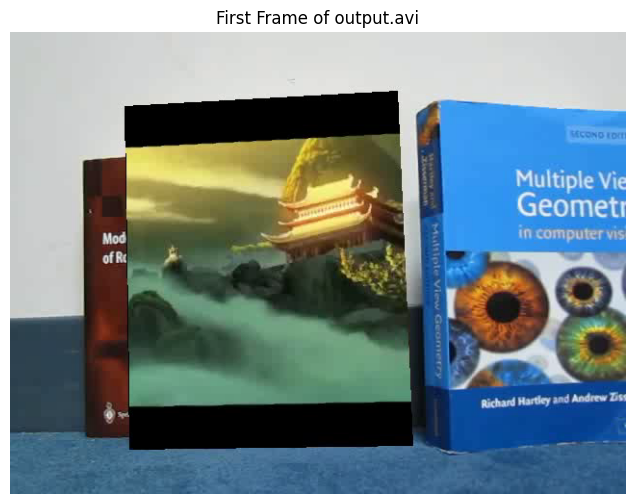

In [9]:
preview_cap = cv2.VideoCapture('output.avi')
ret, preview_frame = preview_cap.read()
preview_cap.release()

if ret:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(preview_frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('First Frame of output.avi')
    plt.show()
else:
    print('Could not read output.avi for preview')